In [1]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0))

CUDA available: True
GPU: NVIDIA H100 NVL


In [3]:
import torch
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
from torchvision.datasets import Food101
from transformers import CLIPModel, CLIPProcessor
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
import os

In [4]:
from huggingface_hub import login
import getpass

hf_token = getpass.getpass("Enter your Hugging Face token: ")
login(token=hf_token)

Enter your Hugging Face token:  ········


In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_name = "openai/clip-vit-base-patch32"
clip_model = CLIPModel.from_pretrained(model_name, use_safetensors=True).to(device)
clip_processor = CLIPProcessor.from_pretrained(model_name)

clip_model.eval()  # inference only, no training

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel(
  (text_model): CLIPTextModel(
    (embeddings): CLIPTextEmbeddings(
      (token_embedding): Embedding(49408, 512)
      (position_embedding): Embedding(77, 512)
    )
    (encoder): CLIPEncoder(
      (layers): ModuleList(
        (0-11): 12 x CLIPEncoderLayer(
          (self_attn): CLIPAttention(
            (k_proj): Linear(in_features=512, out_features=512, bias=True)
            (v_proj): Linear(in_features=512, out_features=512, bias=True)
            (q_proj): Linear(in_features=512, out_features=512, bias=True)
            (out_proj): Linear(in_features=512, out_features=512, bias=True)
          )
          (layer_norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (mlp): CLIPMLP(
            (activation_fn): QuickGELUActivation()
            (fc1): Linear(in_features=512, out_features=2048, bias=True)
            (fc2): Linear(in_features=2048, out_features=512, bias=True)
          )
          (layer_norm2): LayerNorm((512,), eps=1e-05, eleme

In [6]:
test_dataset_raw = Food101(root='./data', split='test', download=True, transform=None)

print(f"Test size: {len(test_dataset_raw)}")
print(f"Classes: {len(test_dataset_raw.classes)}")

class_names = test_dataset_raw.classes
print(class_names[:5])

Test size: 25250
Classes: 101
['apple_pie', 'baby_back_ribs', 'baklava', 'beef_carpaccio', 'beef_tartare']


In [7]:
def format_class_name(name):
    return name.replace("_", " ")

text_prompts = [f"a photo of {format_class_name(c)}, a type of food" for c in class_names]

text_inputs = clip_processor(text=text_prompts, return_tensors="pt", padding=True).to(device)

with torch.no_grad():
    text_output = clip_model.get_text_features(**text_inputs)
    
    if hasattr(text_output, "pooler_output"):
        text_features = text_output.pooler_output
    elif hasattr(text_output, "text_embeds"):
        text_features = text_output.text_embeds
    else:
        text_features = text_output
    
    text_features = text_features / text_features.norm(dim=-1, keepdim=True)

print("Text features shape:", text_features.shape)  # should print [101, 512]

Text features shape: torch.Size([101, 512])


In [8]:
def collate_fn(batch):
    images = [item[0] for item in batch]
    labels = [item[1] for item in batch]
    return images, labels

test_loader = DataLoader(
    test_dataset_raw,
    batch_size=64,
    shuffle=False,
    num_workers=0,     # changed from 4 to 0
    collate_fn=collate_fn
)

In [9]:
all_preds = []
all_top5_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Zero-shot CLIP inference"):
        image_inputs = clip_processor(images=images, return_tensors="pt").to(device)
        
        image_output = clip_model.get_image_features(**image_inputs)
        
        if hasattr(image_output, "pooler_output"):
            image_features = image_output.pooler_output
        elif hasattr(image_output, "image_embeds"):
            image_features = image_output.image_embeds
        else:
            image_features = image_output
        
        image_features = image_features / image_features.norm(dim=-1, keepdim=True)

        similarity = (image_features @ text_features.T) * clip_model.logit_scale.exp()
        probs = similarity.softmax(dim=-1)

        top5 = torch.topk(probs, k=5, dim=-1).indices.cpu().numpy()
        top1 = top5[:, 0]

        all_preds.extend(top1.tolist())
        all_top5_preds.extend(top5.tolist())
        all_labels.extend(labels)

Zero-shot CLIP inference: 100%|██████████████████████████████████████████████████████| 395/395 [04:15<00:00,  1.55it/s]


In [10]:
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_top5_preds = np.array(all_top5_preds)

top1_acc = (all_preds == all_labels).mean() * 100
top5_acc = np.mean([label in top5row for label, top5row in zip(all_labels, all_top5_preds)]) * 100

print(f"\nZero-Shot CLIP Top-1 Accuracy: {top1_acc:.2f}%")
print(f"Zero-Shot CLIP Top-5 Accuracy: {top5_acc:.2f}%")


Zero-Shot CLIP Top-1 Accuracy: 84.19%
Zero-Shot CLIP Top-5 Accuracy: 97.36%


In [11]:
report = classification_report(all_labels, all_preds, target_names=class_names)
print(report)

with open("clip_zeroshot_classification_report.txt", "w") as f:
    f.write(f"Top-1 Accuracy: {top1_acc:.2f}%\n")
    f.write(f"Top-5 Accuracy: {top5_acc:.2f}%\n\n")
    f.write(report)

                         precision    recall  f1-score   support

              apple_pie       0.84      0.58      0.69       250
         baby_back_ribs       0.81      0.83      0.82       250
                baklava       0.88      0.82      0.85       250
         beef_carpaccio       0.77      0.86      0.82       250
           beef_tartare       0.81      0.81      0.81       250
             beet_salad       0.75      0.75      0.75       250
               beignets       0.85      0.92      0.88       250
               bibimbap       0.97      0.94      0.95       250
          bread_pudding       0.56      0.84      0.67       250
      breakfast_burrito       0.80      0.77      0.78       250
             bruschetta       0.85      0.79      0.82       250
           caesar_salad       0.74      0.94      0.83       250
                cannoli       0.86      0.90      0.88       250
          caprese_salad       0.81      0.90      0.85       250
            carrot_cake 

In [12]:
cm = confusion_matrix(all_labels, all_preds)

cm_normalized = cm.astype('float') / cm.sum(axis=1, keepdims=True)
np.fill_diagonal(cm_normalized, 0)

confused_pairs = []
for i in range(len(class_names)):
    j = np.argmax(cm_normalized[i])
    confused_pairs.append((class_names[i], class_names[j], cm_normalized[i, j]))

confused_pairs.sort(key=lambda x: -x[2])
print("Top 10 most confused class pairs:")
for true_c, pred_c, rate in confused_pairs[:10]:
    print(f"{true_c} -> {pred_c}: {rate*100:.1f}%")

Top 10 most confused class pairs:
cup_cakes -> red_velvet_cake: 19.6%
steak -> filet_mignon: 19.2%
apple_pie -> bread_pudding: 18.8%
hamburger -> pulled_pork_sandwich: 13.6%
tuna_tartare -> beef_tartare: 12.8%
filet_mignon -> steak: 12.4%
chocolate_cake -> chocolate_mousse: 10.0%
onion_rings -> fried_calamari: 10.0%
beef_tartare -> tuna_tartare: 9.2%
chocolate_mousse -> chocolate_cake: 9.2%


In [13]:
np.save("clip_zeroshot_preds.npy", all_preds)
np.save("clip_zeroshot_labels.npy", all_labels)
np.save("clip_zeroshot_top5preds.npy", all_top5_preds)

results_summary = {
    "model": "CLIP ViT-B/32 (zero-shot)",
    "top1_accuracy": top1_acc,
    "top5_accuracy": top5_acc,
}
print(results_summary)

{'model': 'CLIP ViT-B/32 (zero-shot)', 'top1_accuracy': np.float64(84.18613861386139), 'top5_accuracy': np.float64(97.36237623762376)}


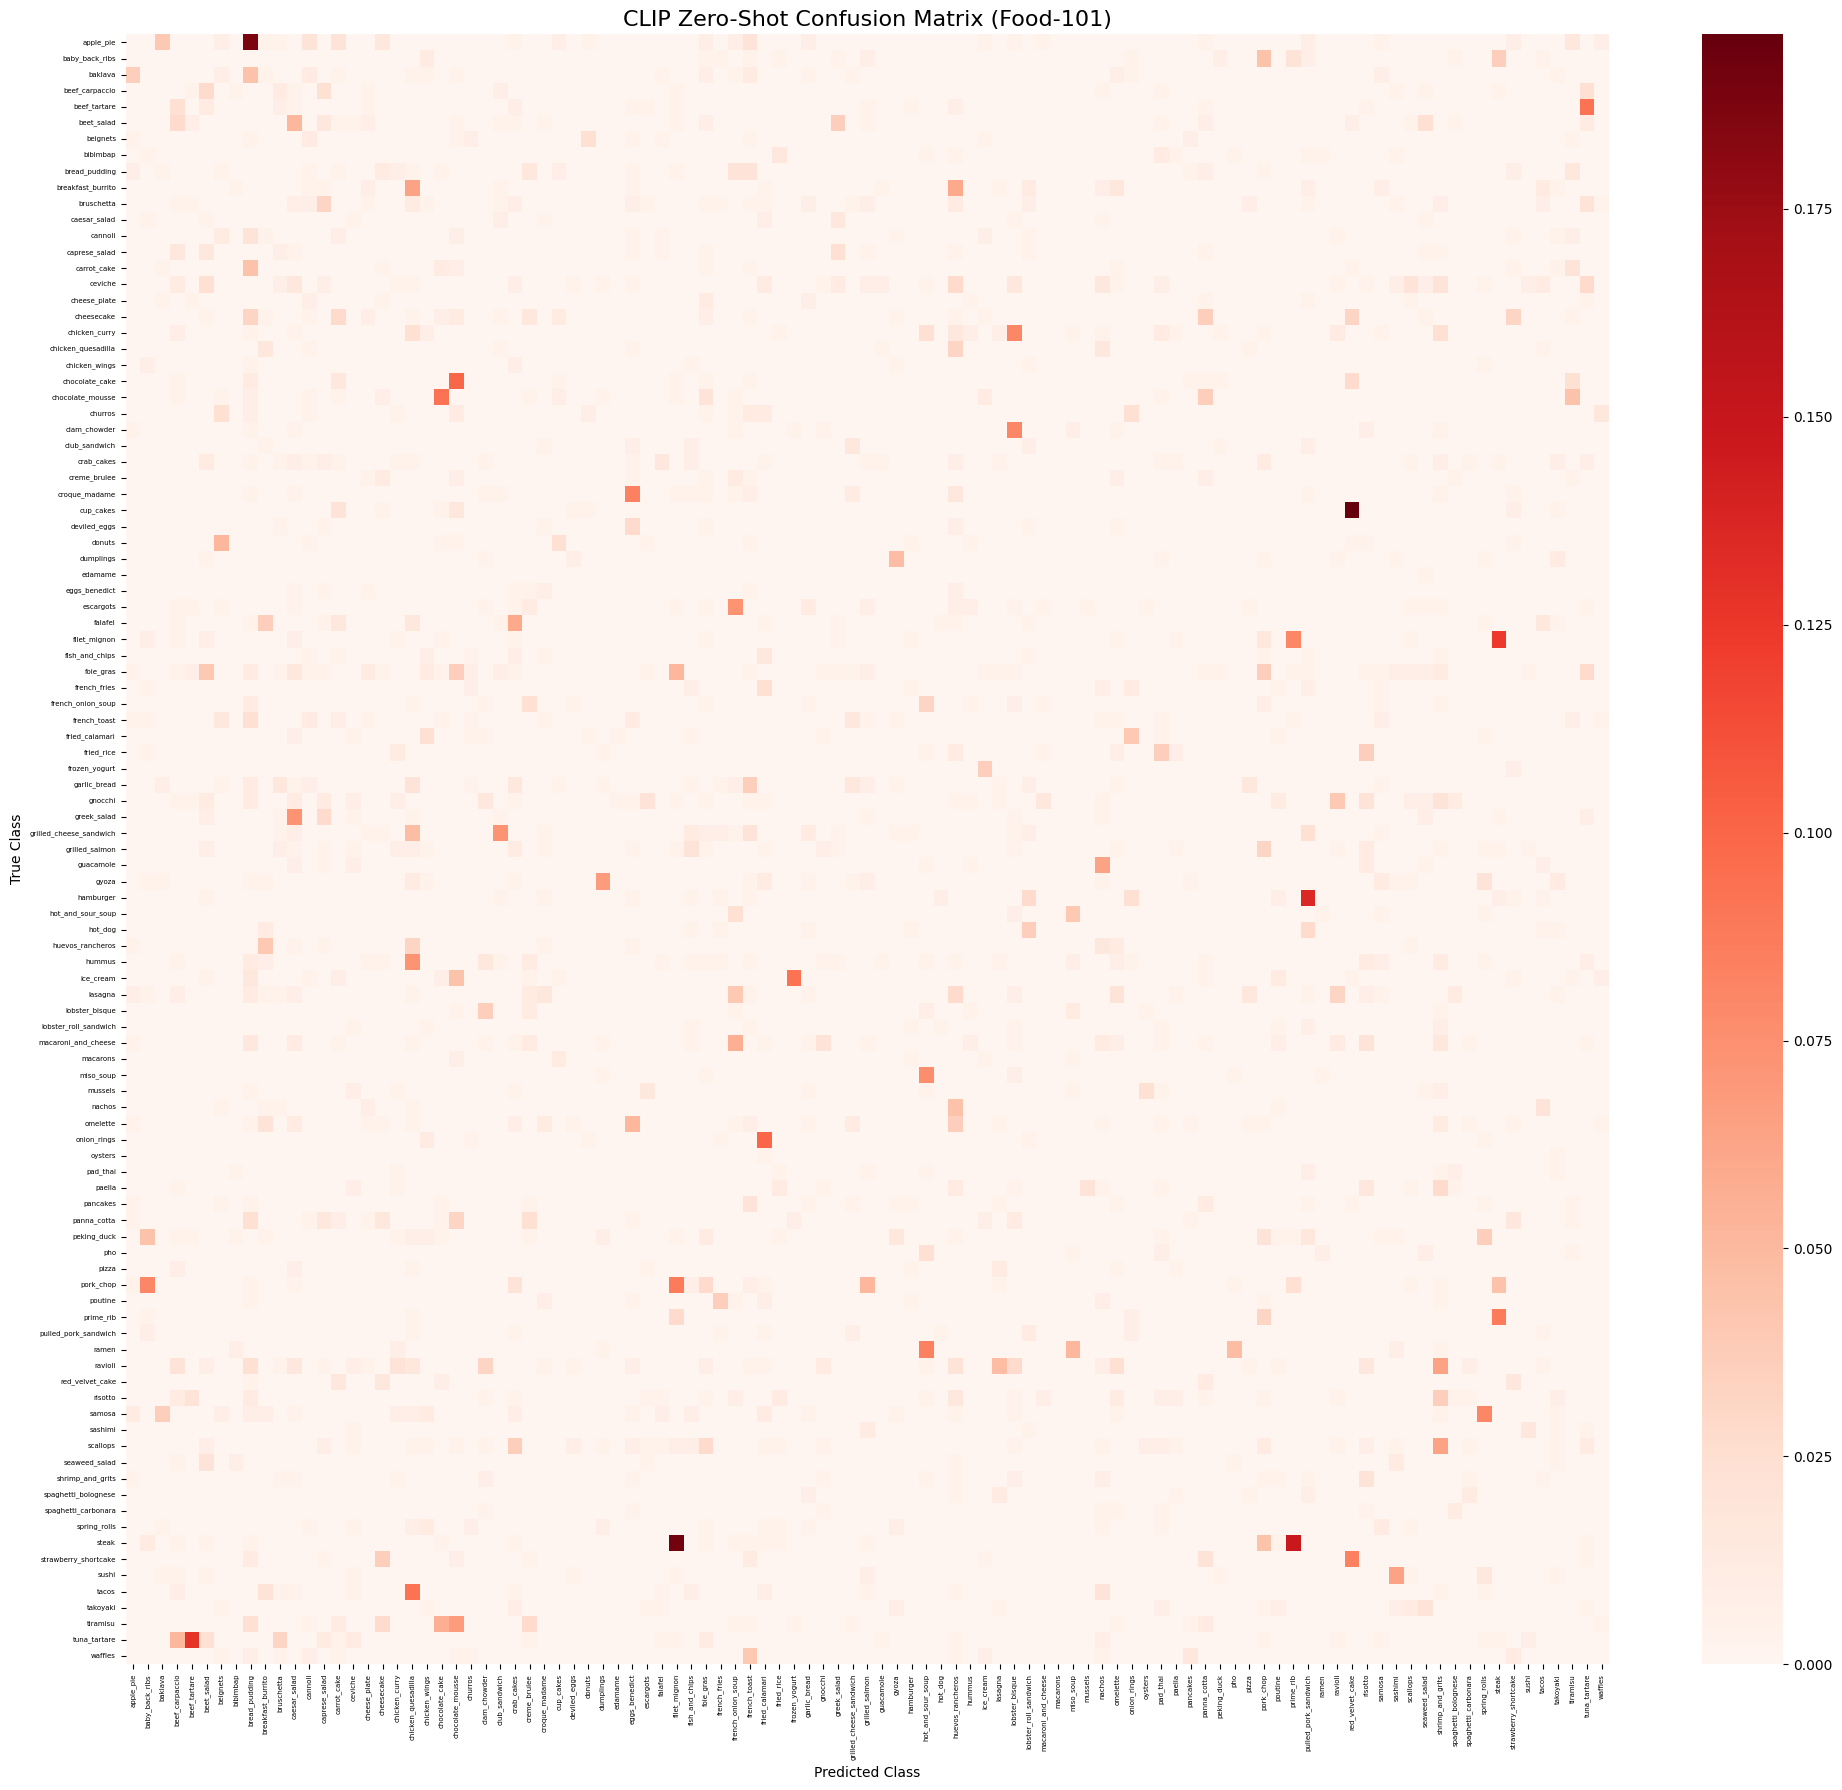

In [14]:
import seaborn as sns

plt.figure(figsize=(20, 18))
sns.heatmap(cm_normalized, cmap="Reds", xticklabels=class_names, yticklabels=class_names)
plt.title("CLIP Zero-Shot Confusion Matrix (Food-101)", fontsize=16)
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.xticks(rotation=90, fontsize=5)
plt.yticks(fontsize=5)
plt.tight_layout()
plt.savefig("clip_confusion_matrix_heatmap.png", dpi=200)
plt.show()

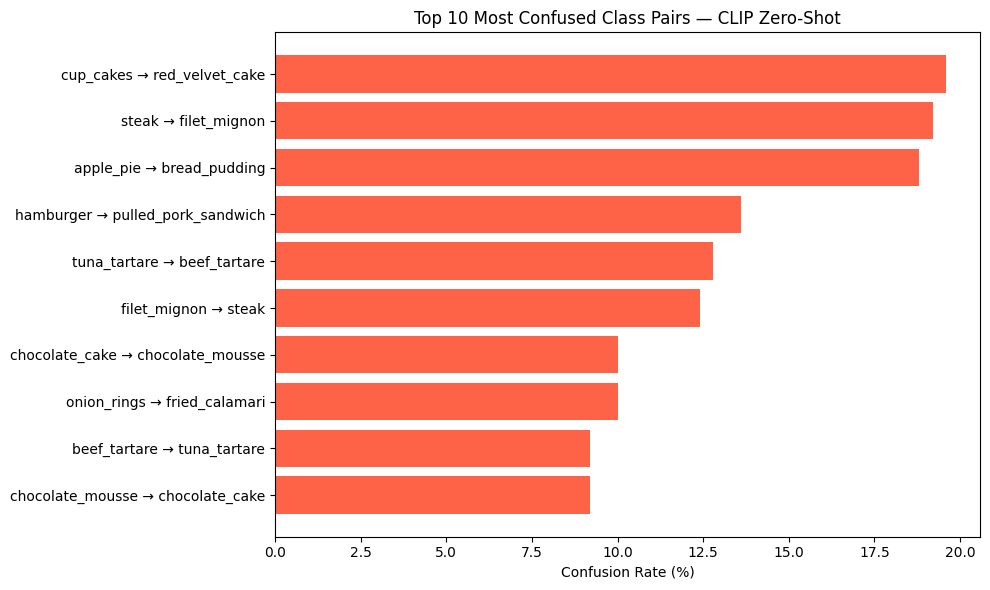

In [15]:
pairs_labels = [f"{a} → {b}" for a, b, _ in confused_pairs[:10]]
pairs_values = [rate * 100 for _, _, rate in confused_pairs[:10]]

plt.figure(figsize=(10, 6))
plt.barh(pairs_labels[::-1], pairs_values[::-1], color="tomato")
plt.xlabel("Confusion Rate (%)")
plt.title("Top 10 Most Confused Class Pairs — CLIP Zero-Shot")
plt.tight_layout()
plt.savefig("clip_top10_confused_pairs.png", dpi=200)
plt.show()

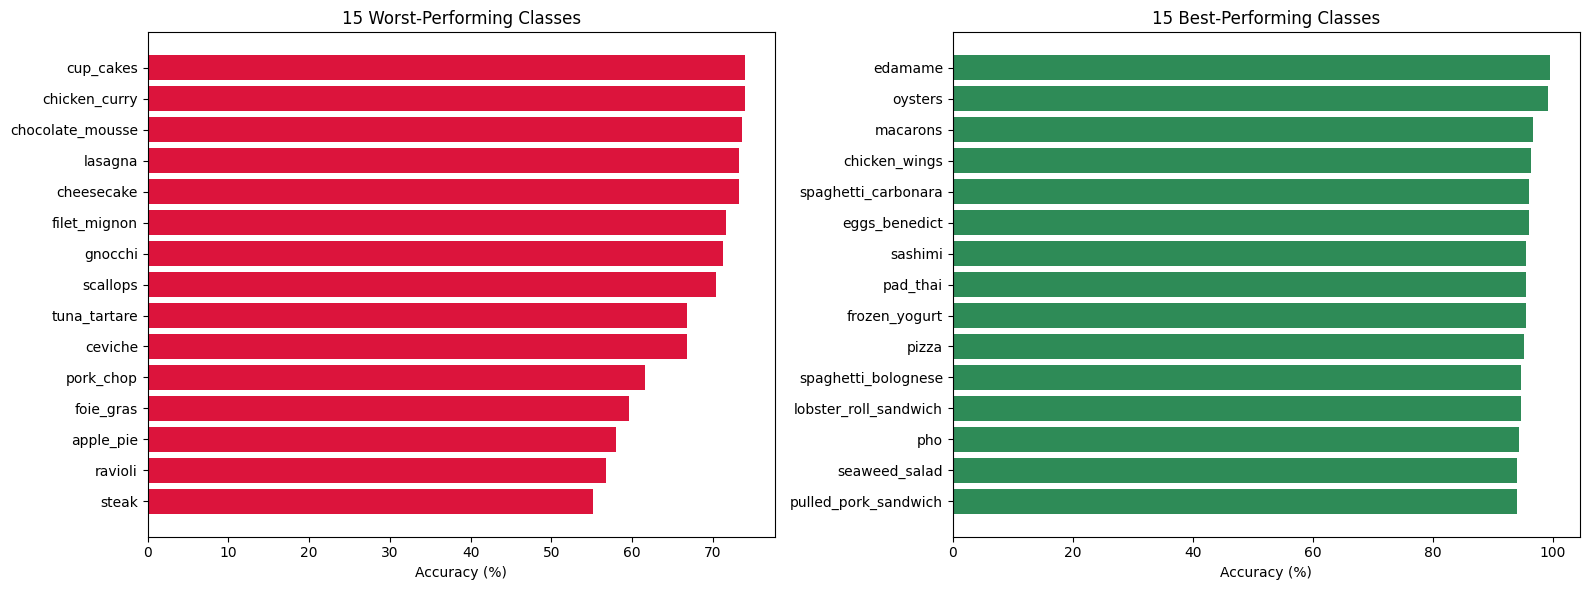

In [16]:
from sklearn.metrics import accuracy_score

per_class_acc = []
for i, cname in enumerate(class_names):
    mask = all_labels == i
    acc = (all_preds[mask] == all_labels[mask]).mean() * 100
    per_class_acc.append((cname, acc))

per_class_acc.sort(key=lambda x: x[1])

worst_15 = per_class_acc[:15]
best_15 = per_class_acc[-15:]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh([x[0] for x in worst_15], [x[1] for x in worst_15], color="crimson")
axes[0].set_title("15 Worst-Performing Classes")
axes[0].set_xlabel("Accuracy (%)")

axes[1].barh([x[0] for x in best_15], [x[1] for x in best_15], color="seagreen")
axes[1].set_title("15 Best-Performing Classes")
axes[1].set_xlabel("Accuracy (%)")

plt.tight_layout()
plt.savefig("clip_per_class_accuracy.png", dpi=200)
plt.show()

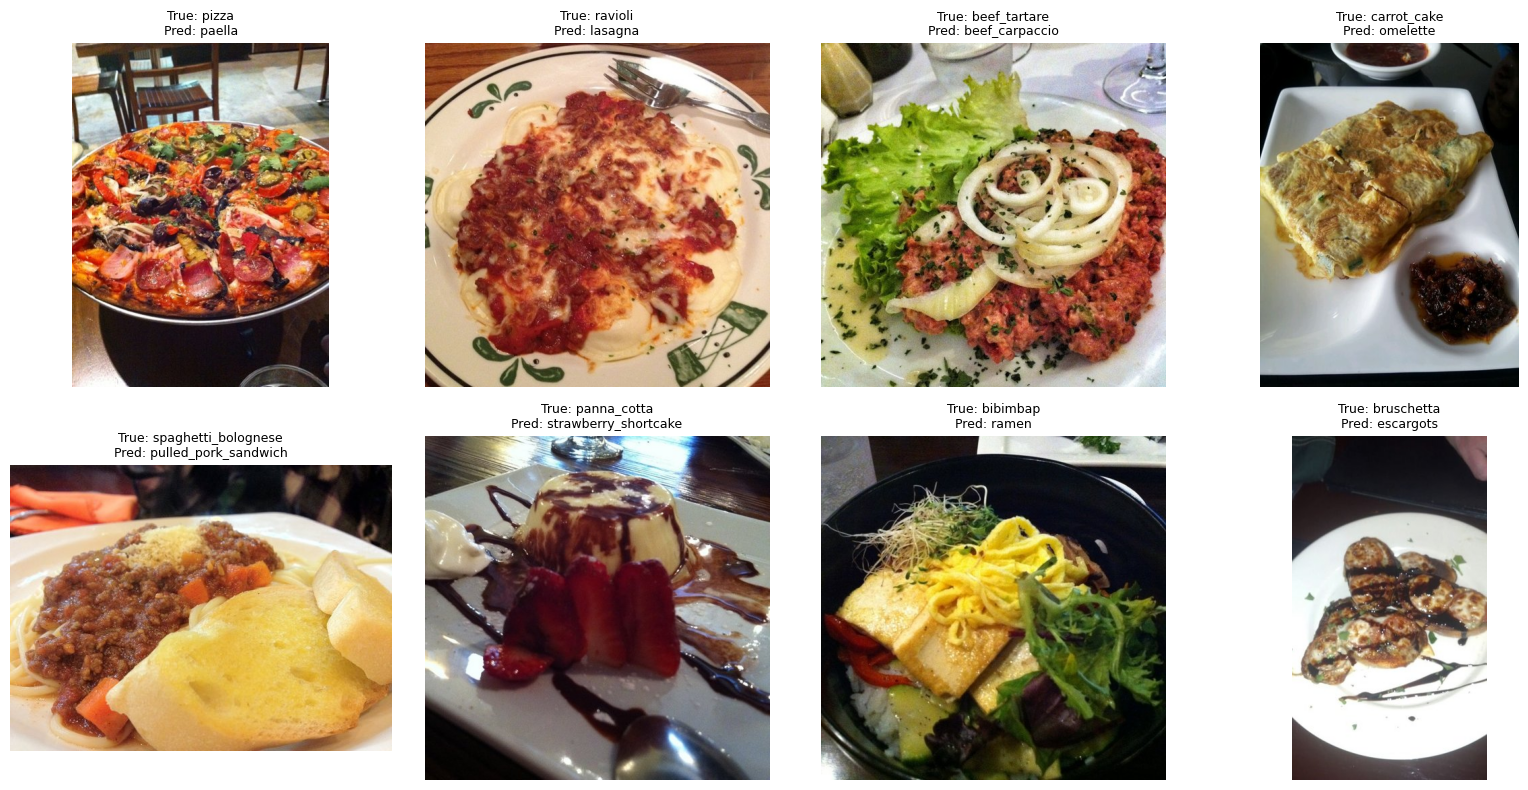

In [18]:
import random

test_dataset_display = Food101(root='./data', split='test', download=False, transform=None)

wrong_indices = np.where(all_preds != all_labels)[0]
sample_wrong = random.sample(list(wrong_indices), 8)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, idx in zip(axes.flatten(), sample_wrong):
    img, true_label = test_dataset_display[idx]
    pred_label = all_preds[idx]
    ax.imshow(img)
    ax.set_title(f"True: {class_names[true_label]}\nPred: {class_names[pred_label]}", fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.savefig("clip_sample_misclassifications.png", dpi=200)
plt.show()